# Reti Neurali

Sono ispirate dalla neuroscienza:

- I neuroni sono collegati tra loro e si trasmettono segnali elettrici a vicenda.
- I neuroni processano segnali di input e possono essere attivati una volta che il segnale supera una certa soglia.

# Rete neurale artificiale

Modello matematico di learning ispirato alle reti neurali biologiche.

- Modellano funzioni matematiche che mappano input a output basandosi sulla struttura e i parametri del network.
- La struttura del network è basata sull'allenamento sui dati.

Quando implementato in IA, il parallelo di ogni neurone è un'**unità** che è connessa alle altre.
Ad esempio, nell'ultima lezione, l'IA ha mappato due input ($x₁$ e $x₂$) all'output che definiva se pioveva o meno. Sempre nell'ultima lezione, abbiamo suggerito la seguente forma della funzione ipotesi:

$$
h(x₁, x₂) = w₀ + w₁x₁ + w₂x₂
$$

- $w₁$ e $w₂$ sono pesi che modificano l'input.
- $w₀$ è una costante, detta **bias**, che modifica il valore di tutta l'espressione.

# Funzioni d'attivazione

Per usare la funzione ipotesi per decidere, ad esempio, se piove o no, dobbiamo creare una soglia basata sul valore che produce.

Ci sono vari metodi:
- Funzione gradino
- Sigmoide logistica
- Tangente iperbolica
- Rectified Linear Unit (ReLU)

## Funzione gradino

$$
g(x) =
\begin{cases}
1 & \text{se } x \geq 0\\
0 & \text{se } x < 0\\
\end{cases}
$$

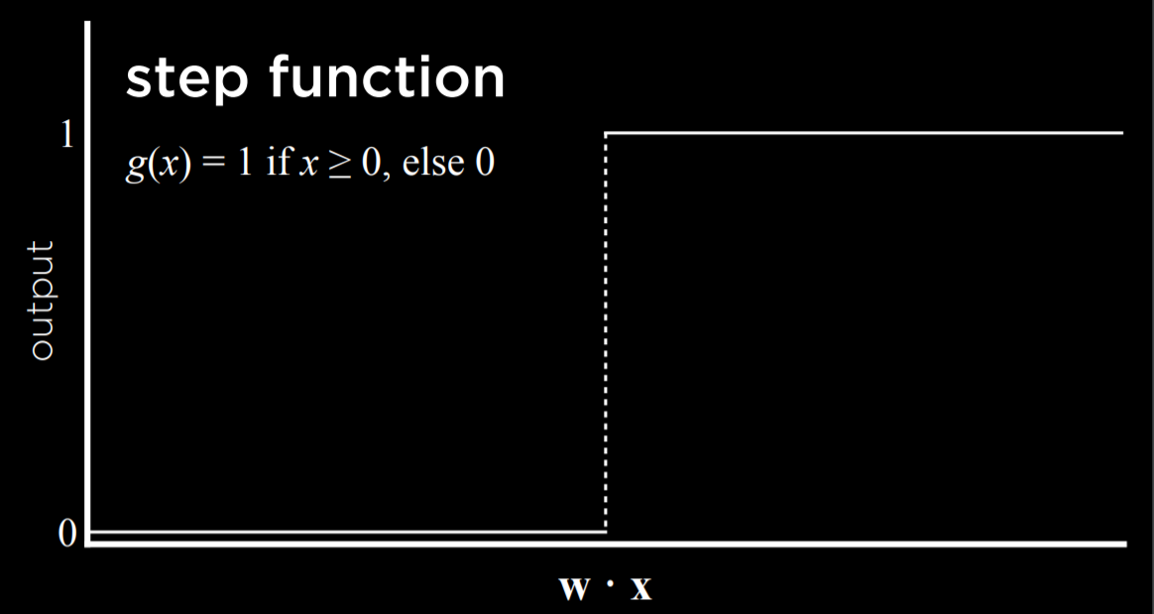

## Sigmoide Logistica

Anche detta funzione logistica. Ha in uscita un numero reale nell'intervallo $[0,1]$, esprimendo quindi una confidenza probabilistica.

$$
g(x)=\frac{e^x}{e^x + 1}
$$

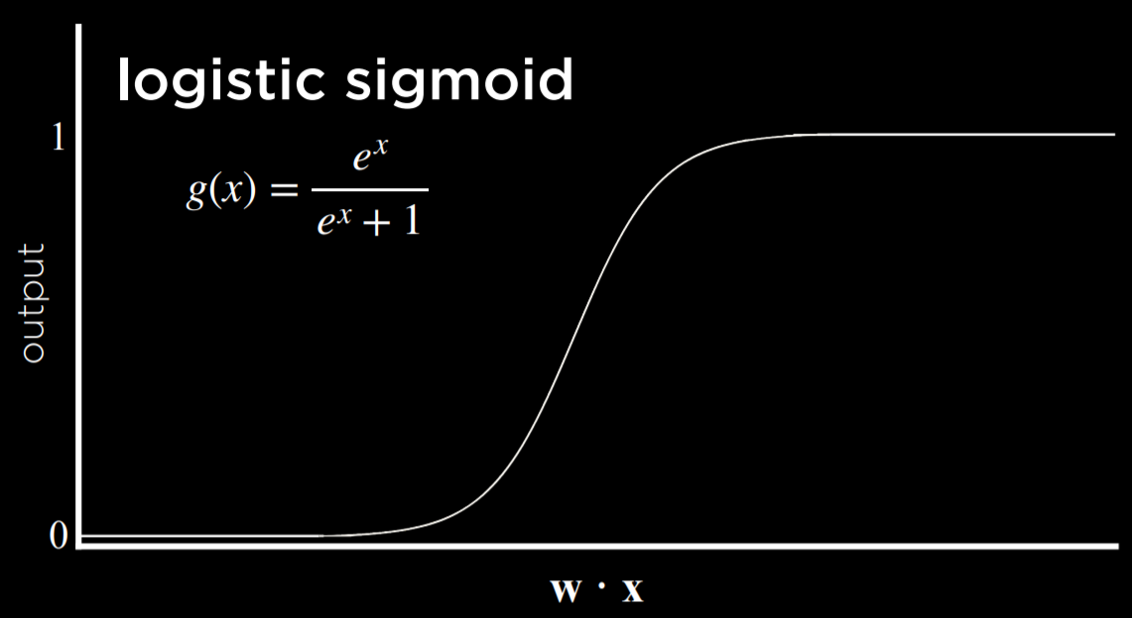

## Tangente iperbolica

Può essere inferita dalla precedente moltiplicando per $2$ e traslando di $-1$ lungo le ordinate.

Posto:

$$
\sigma(x)=\frac{e^x}{e^x + 1}
$$

La funzione Tangente iperbolica $\tau$ è pari a:

$$
\tau(x) = 2\sigma(2x) - 1
$$

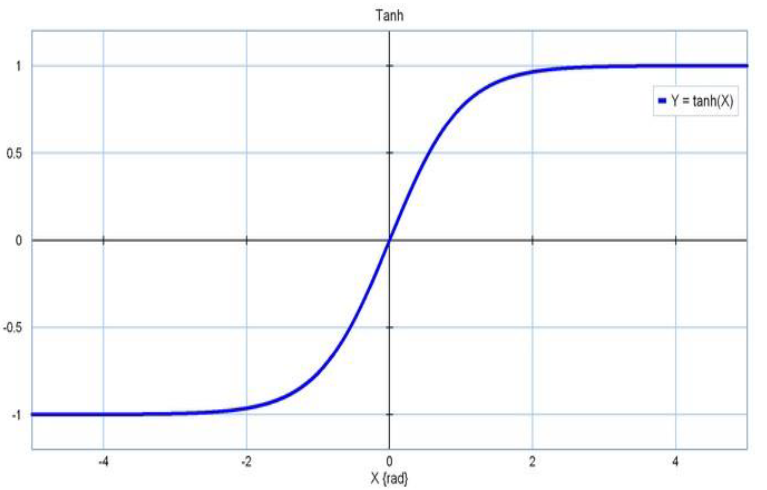

## Rectified Linear Unit (ReLU)

Consente all'output di assumere un qualsiasi valore positivo. Se il valore in uscita è negativo, la ReLU lo fissa a 0.

$$
g(x)=max(0,x)
$$

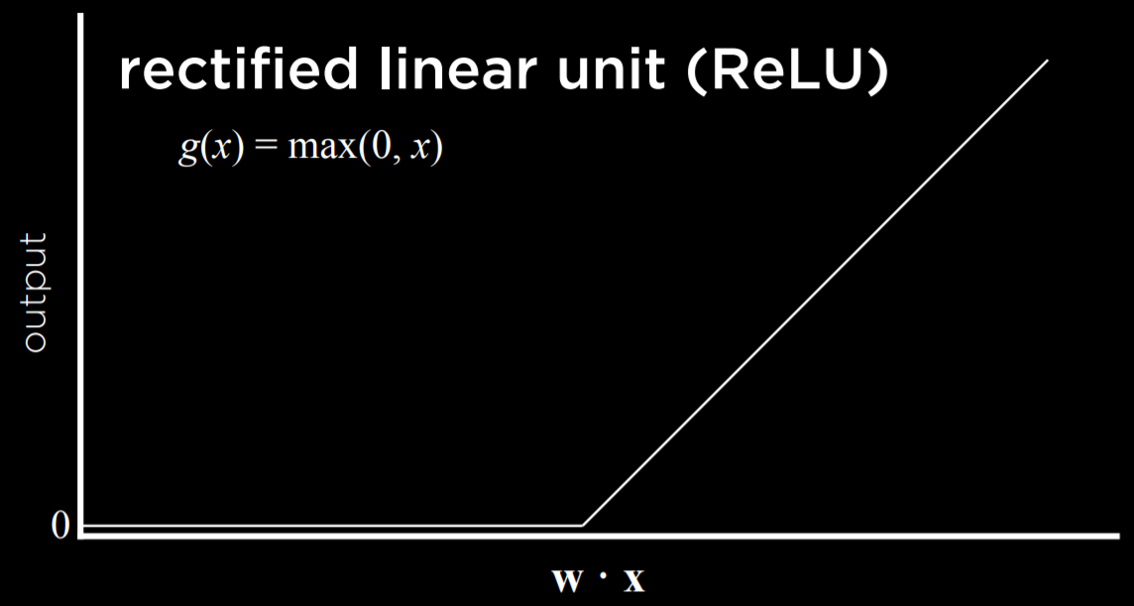

# Struttura di rete neurale

Una rete neurale può essere pensata come una rapprentazione di una delle funzioni sopra:

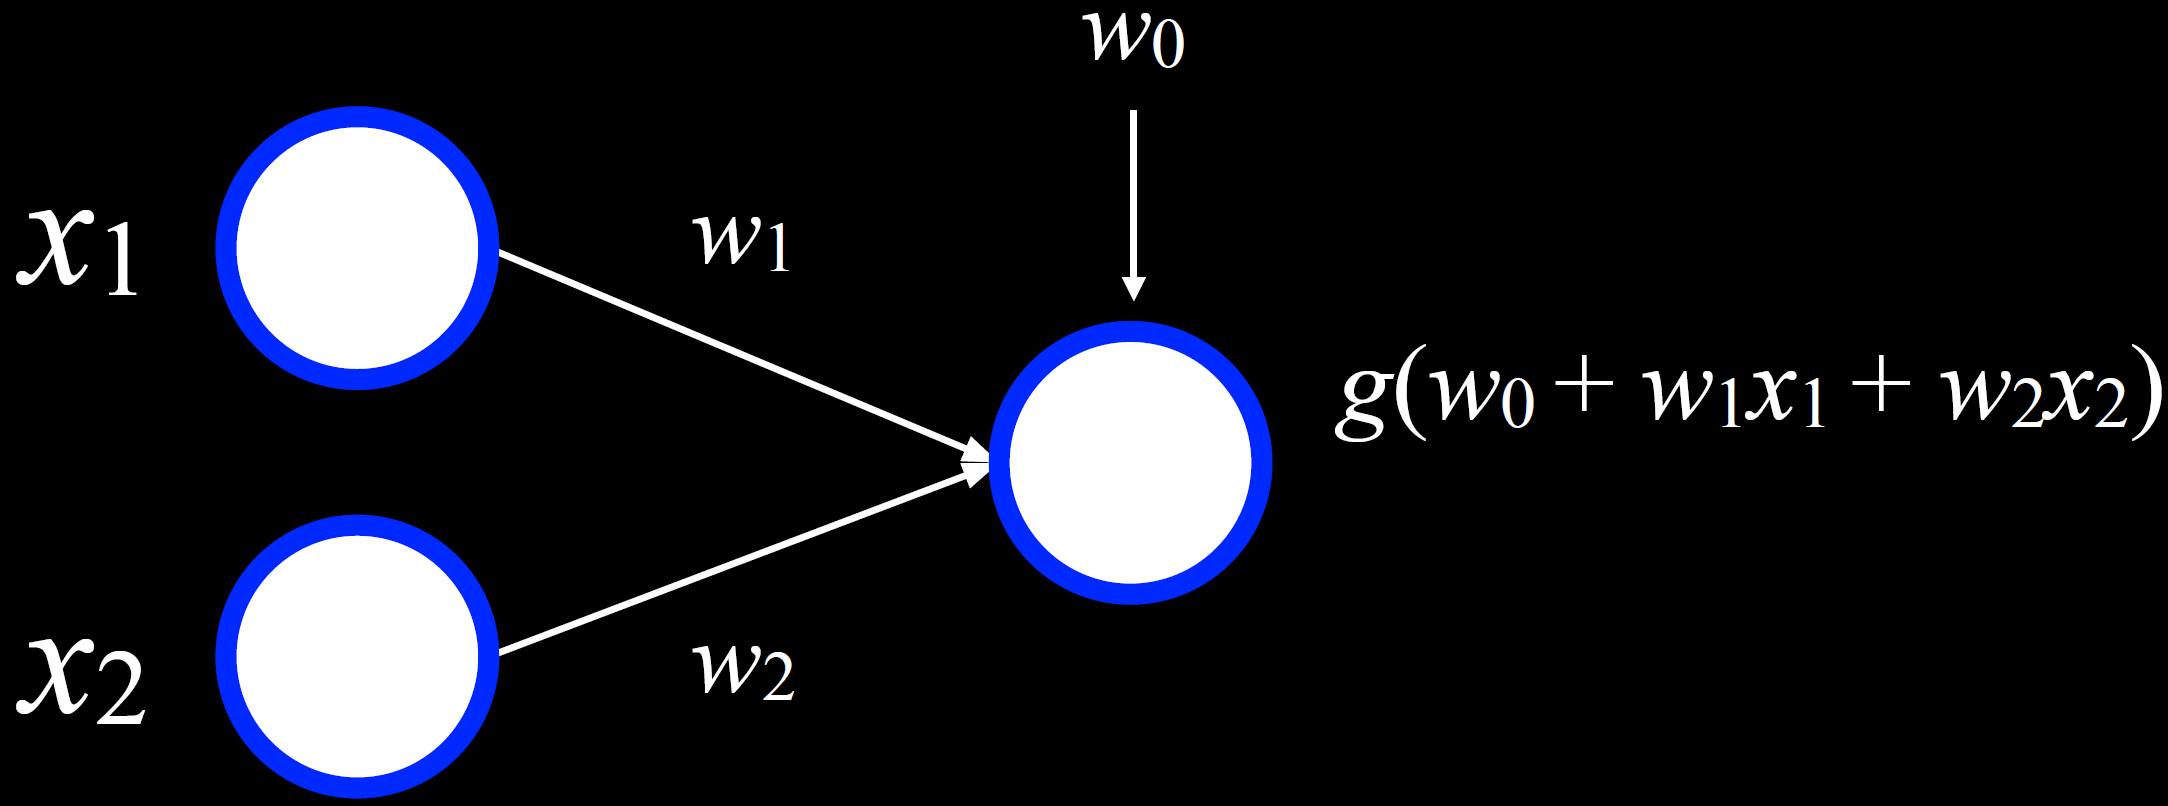

Le due **unità** bianche a sinistra sono gli input, quella a destra è l'output. Gli input sono connessi all'output da un arco pesato.

Per prendere una decisione, l'unità di output moltiplica gli input per i loro pesi, in aggiunta al bias $w₀$, e usa la funzione $g(\cdot)$ per determinare l'output.

## Esempio

Un connettivo logico Or può essere rappresentato come una funzione d'attivazione $f(\cdot)$ con la seguente tabella di verità:

| x | y | $f(x,y)$ |
| :---: | :---: | :---: |
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 1 |

Possiamo visualizzare questa funzione come una rete neurale:

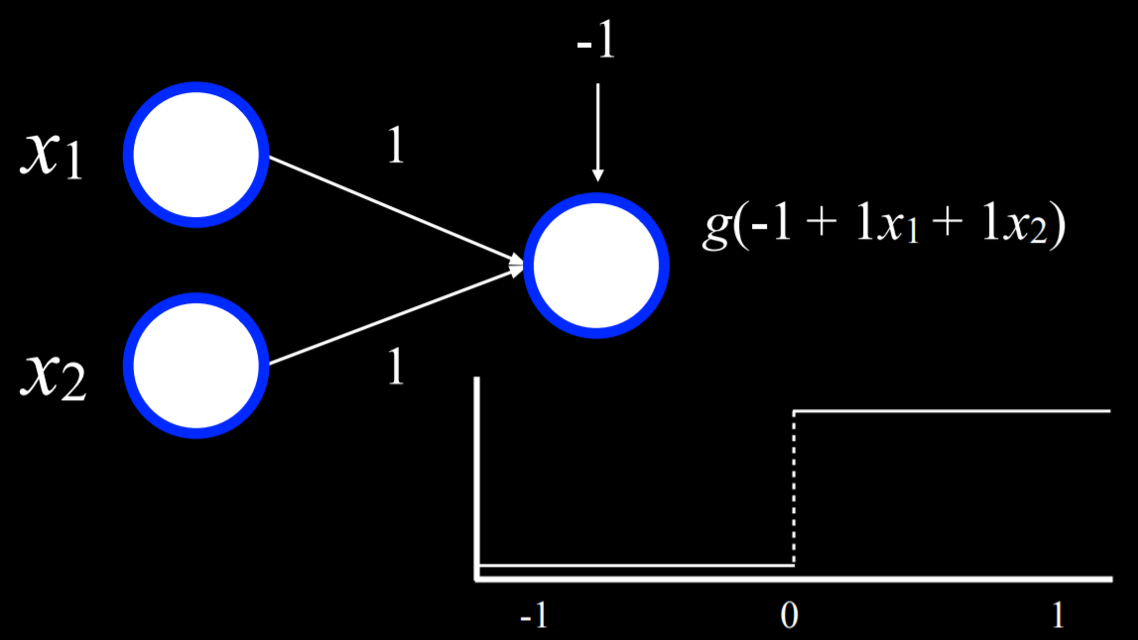

$x₁$ è un'unità di input, $x₂$ è un'altra.

Sono connesse all'unità di output tramite un'arco con un peso di 1.

L'unità di output, poi, usa la funzione $g(-1 + 1x₁ + 1x₂)$ con una soglia di $0$ per dare in output $0$ oppure $1$ (Falso o Vero).

Nel caso in cui $x₁=x₂=0$ la somma è $-1$. Questa è al di sotto della soglia, quindi la funzione $g(\cdot)$ avrà un output pari a $0$.

Tuttavia, se uno o entrambi gli input sono pari a $1$. la loro somma sarà $0$ o $1$. entrambi sono a livello o sopra la soglia, quindi l'output sarà $1$.
___
- Un processo simile può essere ripetuto per la funzione And, dove il bias sarà $-2$. Inoltre, input e output non devono essere distinti.

- Un processo simile può essere usato per prendere umidità e pressione come input e produrre una probabilità di pioggia come output.

- Oppure, con un esempio diverso, gli input possono essere soldi spesi in marketing e il mese in cui sono stati spesi per ottenere l'aspettativa di guadagno come output.

- Questo può essere esteso per ogni numero di input moltiplicando ogni input $x₁ … xₙ$ coi pesi $w₁ … wₙ$, sommando i valori risultanti e poi aggiungendo il bias $w₀$

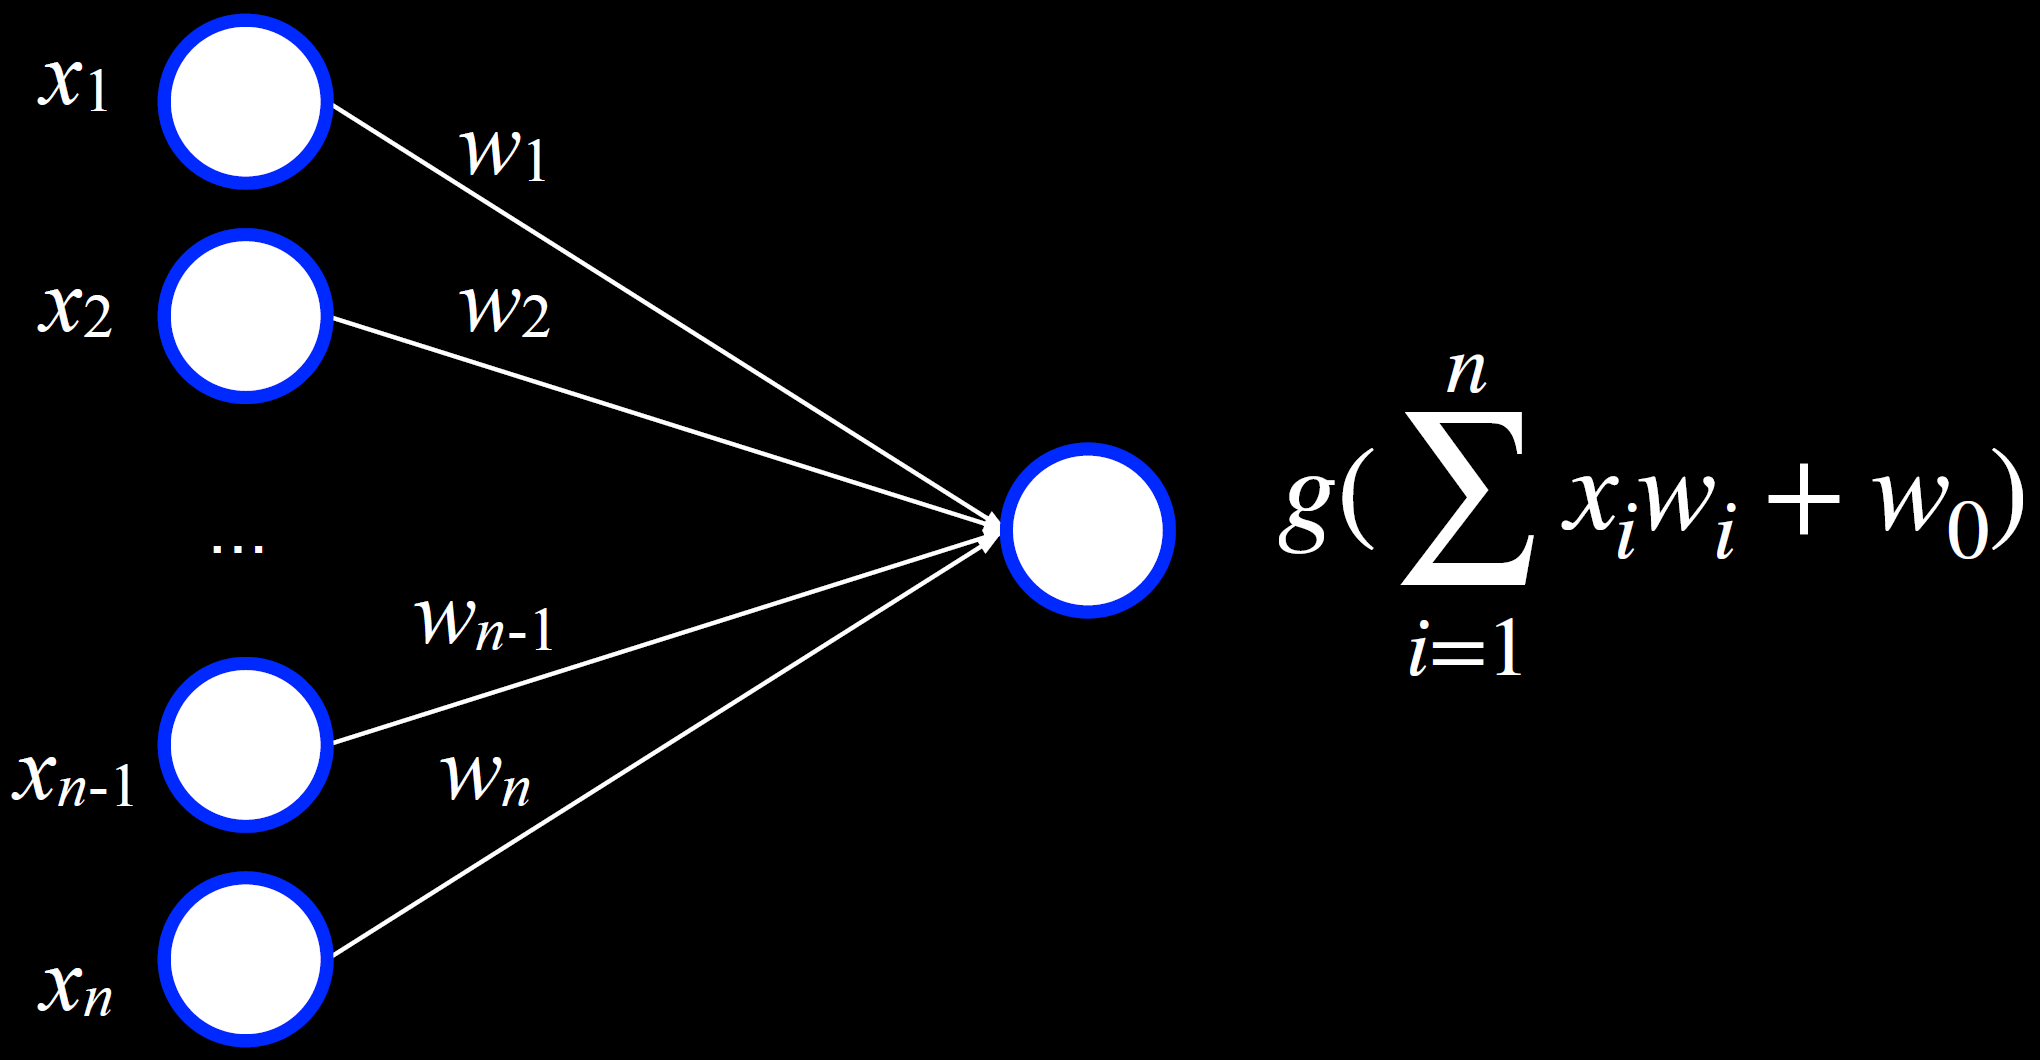

# Gradient Descent

Gradient descent è un algoritmo che minimizza la loss (Ricorda le loss functions) quando si allenano le reti neurali.

Il gradiente è la pendenza della funzione di loss in un punto particolare.

Come detto prima, una rete neurale è in grado di inferire conoscenza sulla struttura della rete stessa dai dati. Finora abbiamo definito i vari pesi, ma le reti neurali ci permettono di calcolare questi pesi basandosi sui dati di training.

Per fare ciò, usiamo l'algoritmo **Gradient Descent**, che funziona nel modo seguente:

* Inizia con una scelta random dei pesi.
  * Questo è il nostro stato iniziale "ingenuo", dove non sappiamo quanto dovrebbe pesare ogni input.
* Ripeti:
  * Calcola il gradiente basandoti su tutti i data point che porteranno a una riduzione della loss. (Il gradiente non è altro che un vettore)
  * Aggiorna i pesi secondo il gradiente

___
Il problema di questo algoritmo è che richiede il calcolo del gradiente basandosi su *tutti* i data points, che è parecchio costoso. Ci sono vari modi di minimizzare i costi:
- Stochastic Gradient Descent
- Mini-Batch Gradient Descent

## Stochastic Gradient Descent

Il gradiente è calcolato basandosi su un punto scelto casualmente. L'algoritmo è:

* Inizia con una scelta random dei pesi.
* Ripeti:
  * Calcola il gradiente basandoti su **un solo** data point che porterà a una riduzione della loss.
  * Aggiorna i pesi secondo il gradiente

Questo tipo di gradiente può essere molto inaccurato. Ciò porta al:

## Mini-Batch Gradient Descent

Questo algoritmo, invece, calcola il gradiente basandosi su vari punti selezionati casualmente, trovando un compromesso tra costo computazionale e accuratezza.

* Inizia con una scelta random dei pesi.
* Ripeti:
  * Calcola il gradiente basandoti su **un piccolo gruppo** di data point che porteranno a una riduzione della loss.
  * Aggiorna i pesi secondo il gradiente

Come spesso è il caso, nessuna di queste soluzioni è perfetta e ognuna ha i suoi casi di utilizzo.

### Esempio

Vogliamo sapere un'informazione migliore di "Oggi piove?"

Possiamo usare alcuni input per generare probabilità di tipi diversi ti meteo, per poi semplicemente scegliere il più probabile:

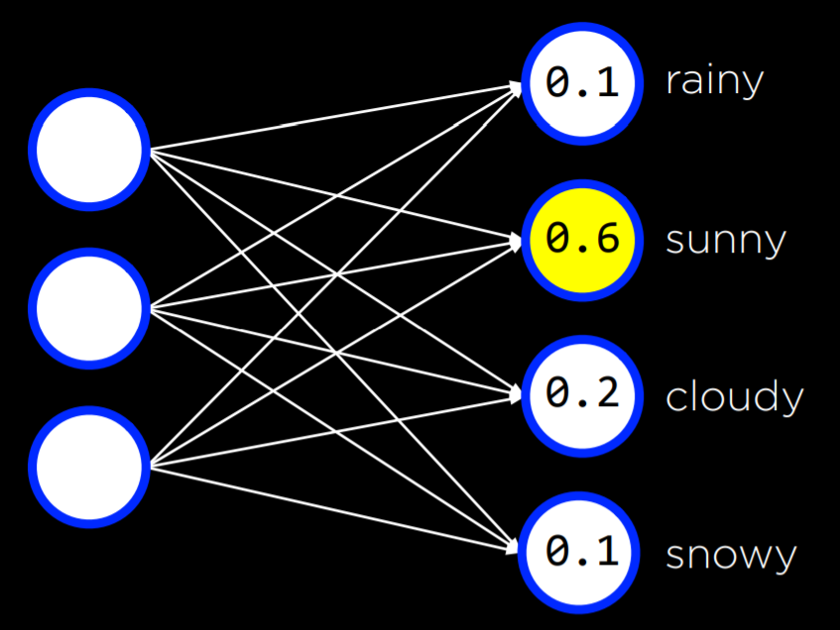

Questo può essere fatto per un numero qualsiasi di input e output, in cui ogni input è connesso a ogni output, e gli output rappresentano scelte che possiamo fare.

Nota che in questo tipo di rete gli output non sono connessi tra loro, quindi ogni output ha pesi specifici associati a ogni input. Possono quindi essere visti come reti neurali diverse ed essere allenate separatamente.

### Limite dell'unità Perceptron

Finora, le nostre reti neurali si sono basate su unità di output **perceptron**.

Queste unità sono in grado di imparare solo una separazione lineare di superfici decisionali, separando i dati con una linea. Cioè, basandosi su un'equazione lineare, il perceptron può classificare un input in una classe o l'altra (Immagine a sinistra)

Tuttavia, spesso i dati non sono separabili linearmente (Immagine a destra). In questo caso ricorriamo a reti neurali multistrato per modellare i dati in maniera non lineare.

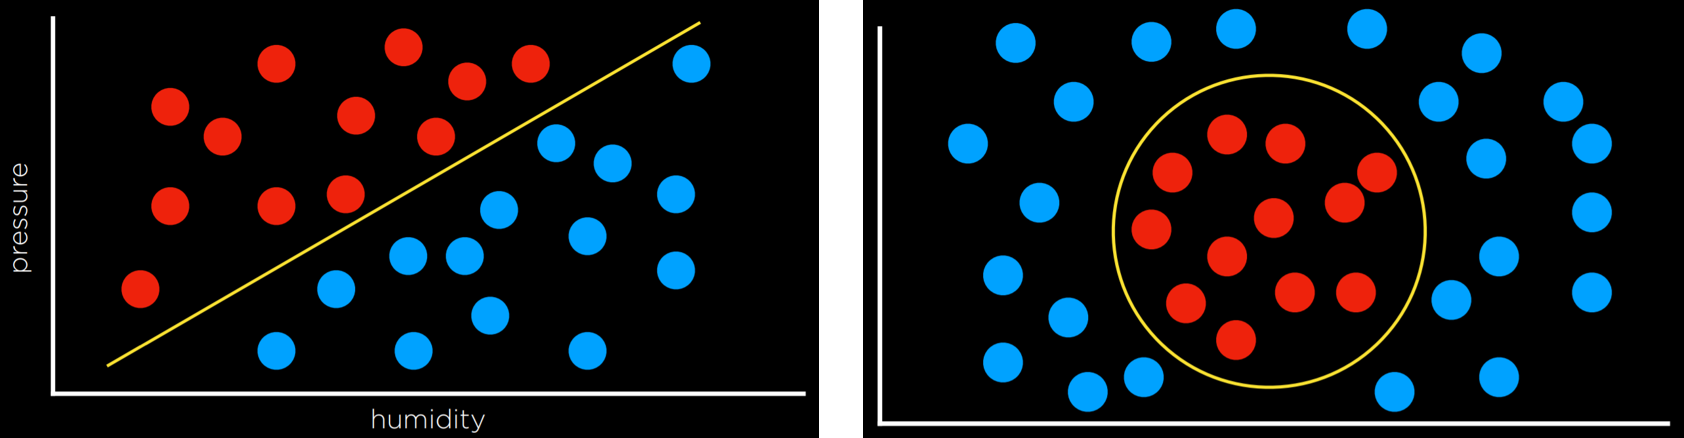

# Reti Neurali Multistrato

Una rete neurale multistrato è una rete neurale artificiale composta da:

* Uno strato di input
* Uno strato di output
* Almeno uno strato **nascosto**

Mentre noi umani provvediamo a dare input e output per addestrare il modello, non diamo nessun valore alle unità nello strato nascosto.

Ogni unità nel primo strato nascosto riceve un valore pesato da ogni unità nello strato di input, effettua un'azione su di esso, e produce in uscita un altro valore.

Ognuno di questi nuovi valori è pesato e ulteriormente propagato allo strato successivo, ripetendo il processo finché non viene raggiunto lo strato di output.

Attraverso gli strati nascosti è possibile modellare dati non lineari, dal momento che ogni nodo può imparare caratteristiche diverse degli input.

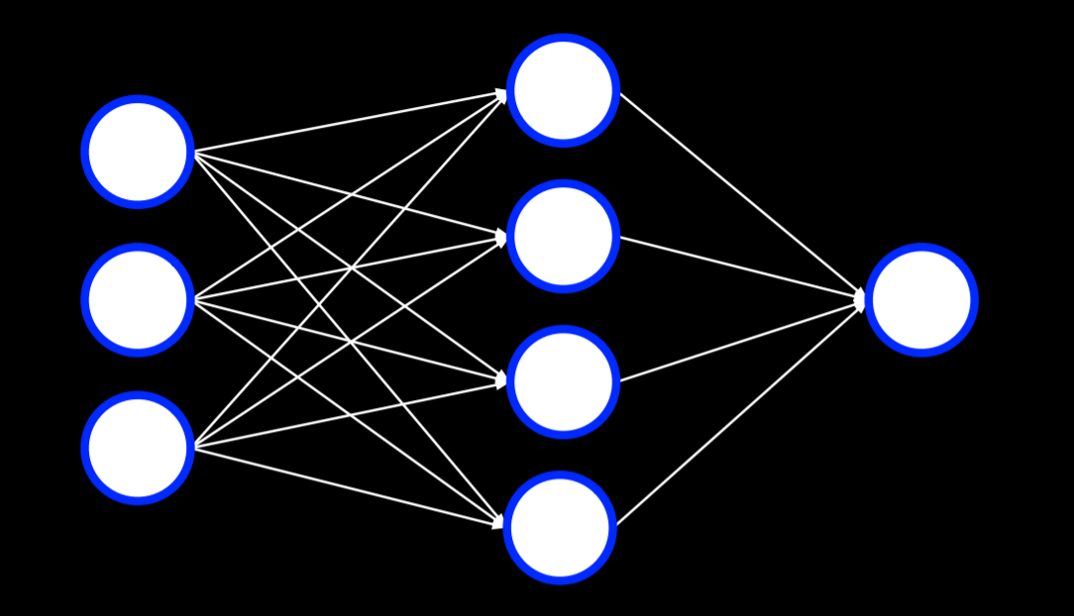

Come facciamo ad addestrare una rete neurale con strati nascosti, se non possiamo raggiungerli o osservarli? Ricorriamo all'algoritmo di **Backpropagation**

## Backpropagation

Backpropagation è l'algoritmo principale usato per addestrare reti neurali multistrato.

Inizia valutando gli errori e/o la loss function alle unità di output, calcolando il gradient descent per i pesi degli strati precedenti e ripetendo il processo finché non si raggiunge lo strato di input.

In pseudocodice:

* Iniziamo con una scelta casuale di pesi
* Ripeti:
  * Calcola l'errore per lo strato di output
  * Per ogni strato, iniziando da quello di output e muovendoti verso il primo strato nascosto:
    - Propaga l'errore all'indietro di uno strato. (Lo strato attuale considerato invia gli errori a quello precedente)
    - Aggiorna i pesi

Questo può essere esteso a un qualsiasi numero di strati nascosti, creando **Deep neural networks**, che sono reti neurali che hanno più di uno strato nascosto.

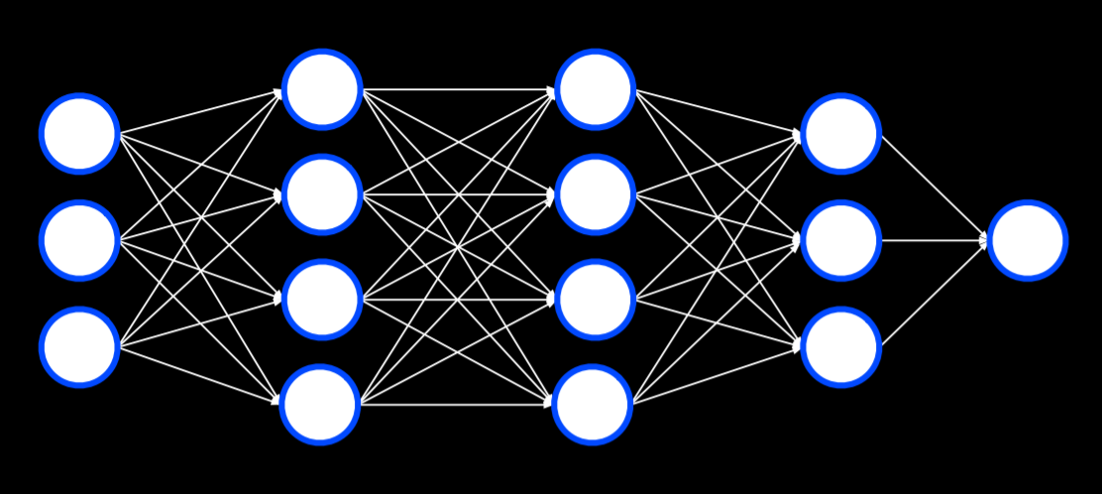

## Overfitting

Overfitting è il pericolo di modellare i dati di addestramento in maniera troppo vicina, fallendo nel generalizzare nuovi dati. Un modo di combattere l'overfitting è tramite **dropout**.

Con questa tecnica, rimuoviamo temporaneamente unità, selezionate randomicamente, durante la fase di apprendimento. In questo modo, cerchiamo di prevenire la dipendenza eccessiva su una singola unità del network.

Attraverso l'addestramento, la ret eneurale assumerà diverse forme, ogni volta lasciando andare (*dropping*) qualche unità per poi riutilizzarle:

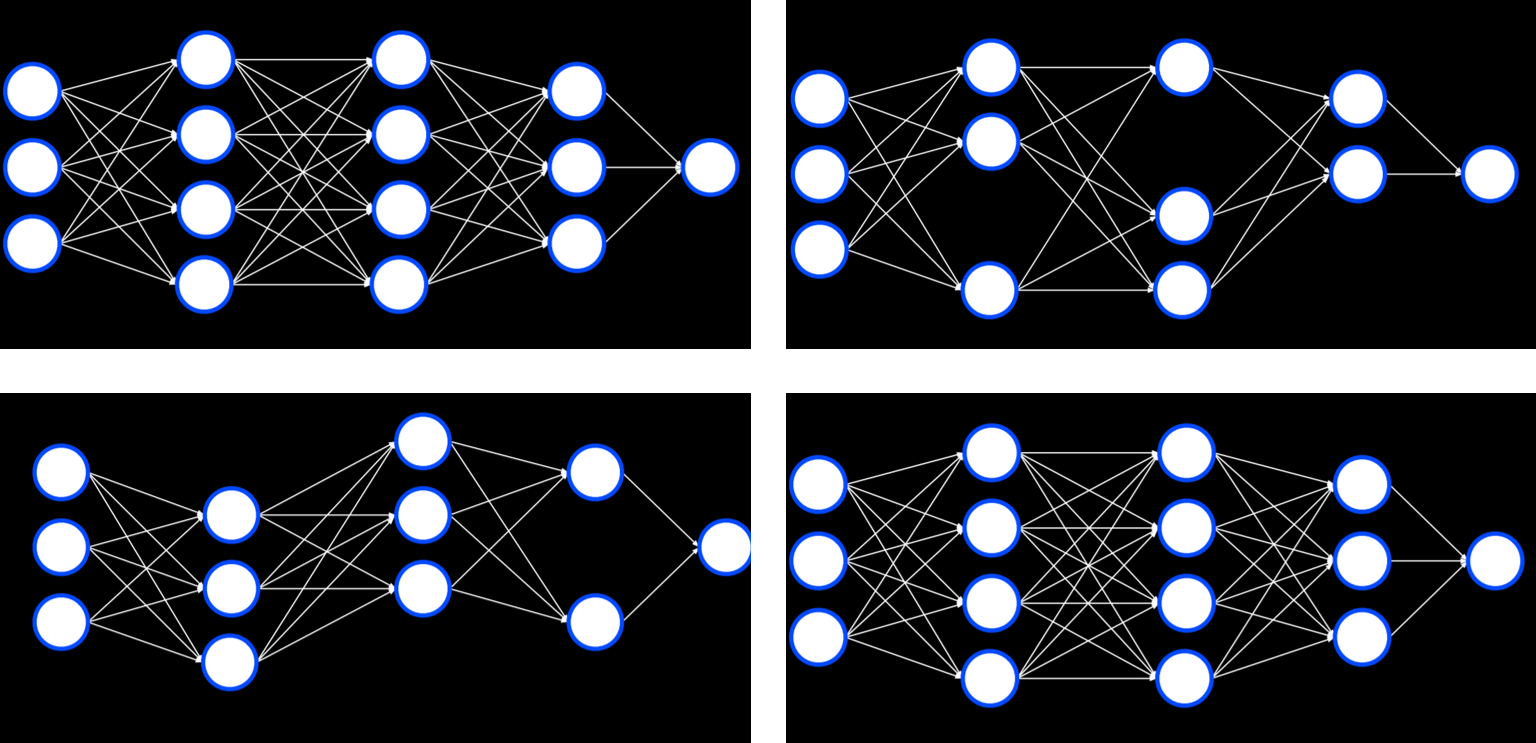

## TensorFlow (Libreria)

TensorFlow è una libreria che contiene già implementazioni per le reti neurali usando l'algoritmo di Backpropagation.

In questa [web application](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.77007&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) si può sperimentare con le reti neurali tramite TensorFlow, definendo proprietà differenti e mandandole in esecuzione, visualizzando poi l'output.

## Esempio di Rete con TensorFlow

Usiamo TensorFlow per effettuare la task della lezione precedente: distinguere tra banconote vere e contraffatte. Il file col codice è: [banknotes.py]()

Importiamo le librerie. Chiamiamo TensorFlow come tf e numpy come np per semplicità.

In [17]:
import csv
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

___
Diamo i dati CSV al modello. Spesso serve il nostro lavoro per adattare i dati al formato che la libreria richiede. TensorFlow lavora principalmente con NumpPy.

La parte difficile di codificare effettivamente il modello è già stata implementata per noi.

In [18]:
# Read data in from file
with open("banknotes\\banknotes.csv") as f:
    reader = csv.reader(f)
    next(reader)

    data = []
    for row in reader:
        data.append({
            "evidence": [float(cell) for cell in row[:4]],
            "label": 1 if row[4] == "0" else 0
        })

# Separate data into training and testing groups
evidence = np.array([row["evidence"] for row in data])
labels = np.array([row["label"] for row in data])
X_training, X_testing, y_training, y_testing = train_test_split(
    evidence, labels, test_size=0.4
)

___
Keras è un API a cui accedono vari algoritmi di Machine Learning.

Un modello sequenziale è quando gli strati si susseguono, come quelli che abbiamo visto appena prima.

In [19]:
# Create a neural network
model = tf.keras.models.Sequential()

___
Uno strato denso è quando ogni nodo dello strato corrente è connesso a tutti i nodi dello strato precedente.

Generando i nostri strati nascosti, creiamo 8 strati densi, ognuno avente 4 neuroni di input, usando l'activation function ReLU vista sopra.

In [20]:
# Add a hidden layer with 8 units, with ReLU activation
model.add(tf.keras.layers.Dense(8, input_shape=(4,), activation="relu"))

d:\Uni\Tesi\CS50AI\.conda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


___
Nel nostro strato di output, vogliamo creare uno strato denso che usa una logistical sigmoid come funzione d'attivazione, il cui codominio è l'intervallo (0,1)

In [21]:
# Add output layer with 1 unit, with sigmoid activation
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

___
Infine compiliamo il modello, specificando quale algoritmo deve ottimizzarlo, quale loss function usiamo e come vogliamo misurare il suo successo. Nel nostro caso, siamo interessati all'accuratezza dell'output.

Finalmente, facciamo fit del modello sul Training Set con 20 ripetizioni (epoche), poi valutiamo il Testing Set.

In [24]:
# Train neural network
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.fit(X_training, y_training, epochs=20)

# Evaluate how well model performs
model.evaluate(X_testing, y_testing, verbose=2)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 882us/step - accuracy: 0.9608 - loss: 0.1421
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9735 - loss: 0.1292   
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9741 - loss: 0.1185
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9877 - loss: 0.1040
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9845 - loss: 0.0977 
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9910 - loss: 0.0763  
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9890 - loss: 0.0823
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - accuracy: 0.9905 - loss: 0.0788
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9989 - loss: 0.0695
Epoch 10/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9955 - loss: 0.0719
Epoch 11/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9983 - loss: 0.0557
Epoch 12/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0

[0.028202611953020096, 1.0]

# Computer Vision

Computer Vision include tutti i vari metodi computazionali per analizzare e capire le immagini digitali, ed è spesso ottenuta tramite reti neurali.

Le immagini consistono di pixel, e i pixel sono rappresentati da tre valori nell'intervallo [0,255]: uno per rosso, uno per verde e uno per blu. Ci si riferisce a questi valori con l'acronimo RGB.

Possiamo usare questo concetto per creare una rete neurale dove ogni valore di colore in ogni pixel è un input, abbiamo degli strati nascosti, e l'output è un numero di unità che rappresentano cos'è stato mostrato nell'immagine.

Tuttavia, ci sono alcuni inconvenienti in quest'approccio:

Innanzitutto, scomponendo l'immagine in pixel e i valori dei loro colori, non possiamo usare la struttura originale dell'immagine come aiuto. Come umani, se vediamo una parte di un volto, sappiamo di aspettarci il resto del viso, velocizzando la computazione. Vogliamo usare un vantaggio simile nelle nostre reti neurali.

Secondo problema: il volume dei valori di input è estremamente elevato, il che vuol dire calcolare *tanti* pesi.

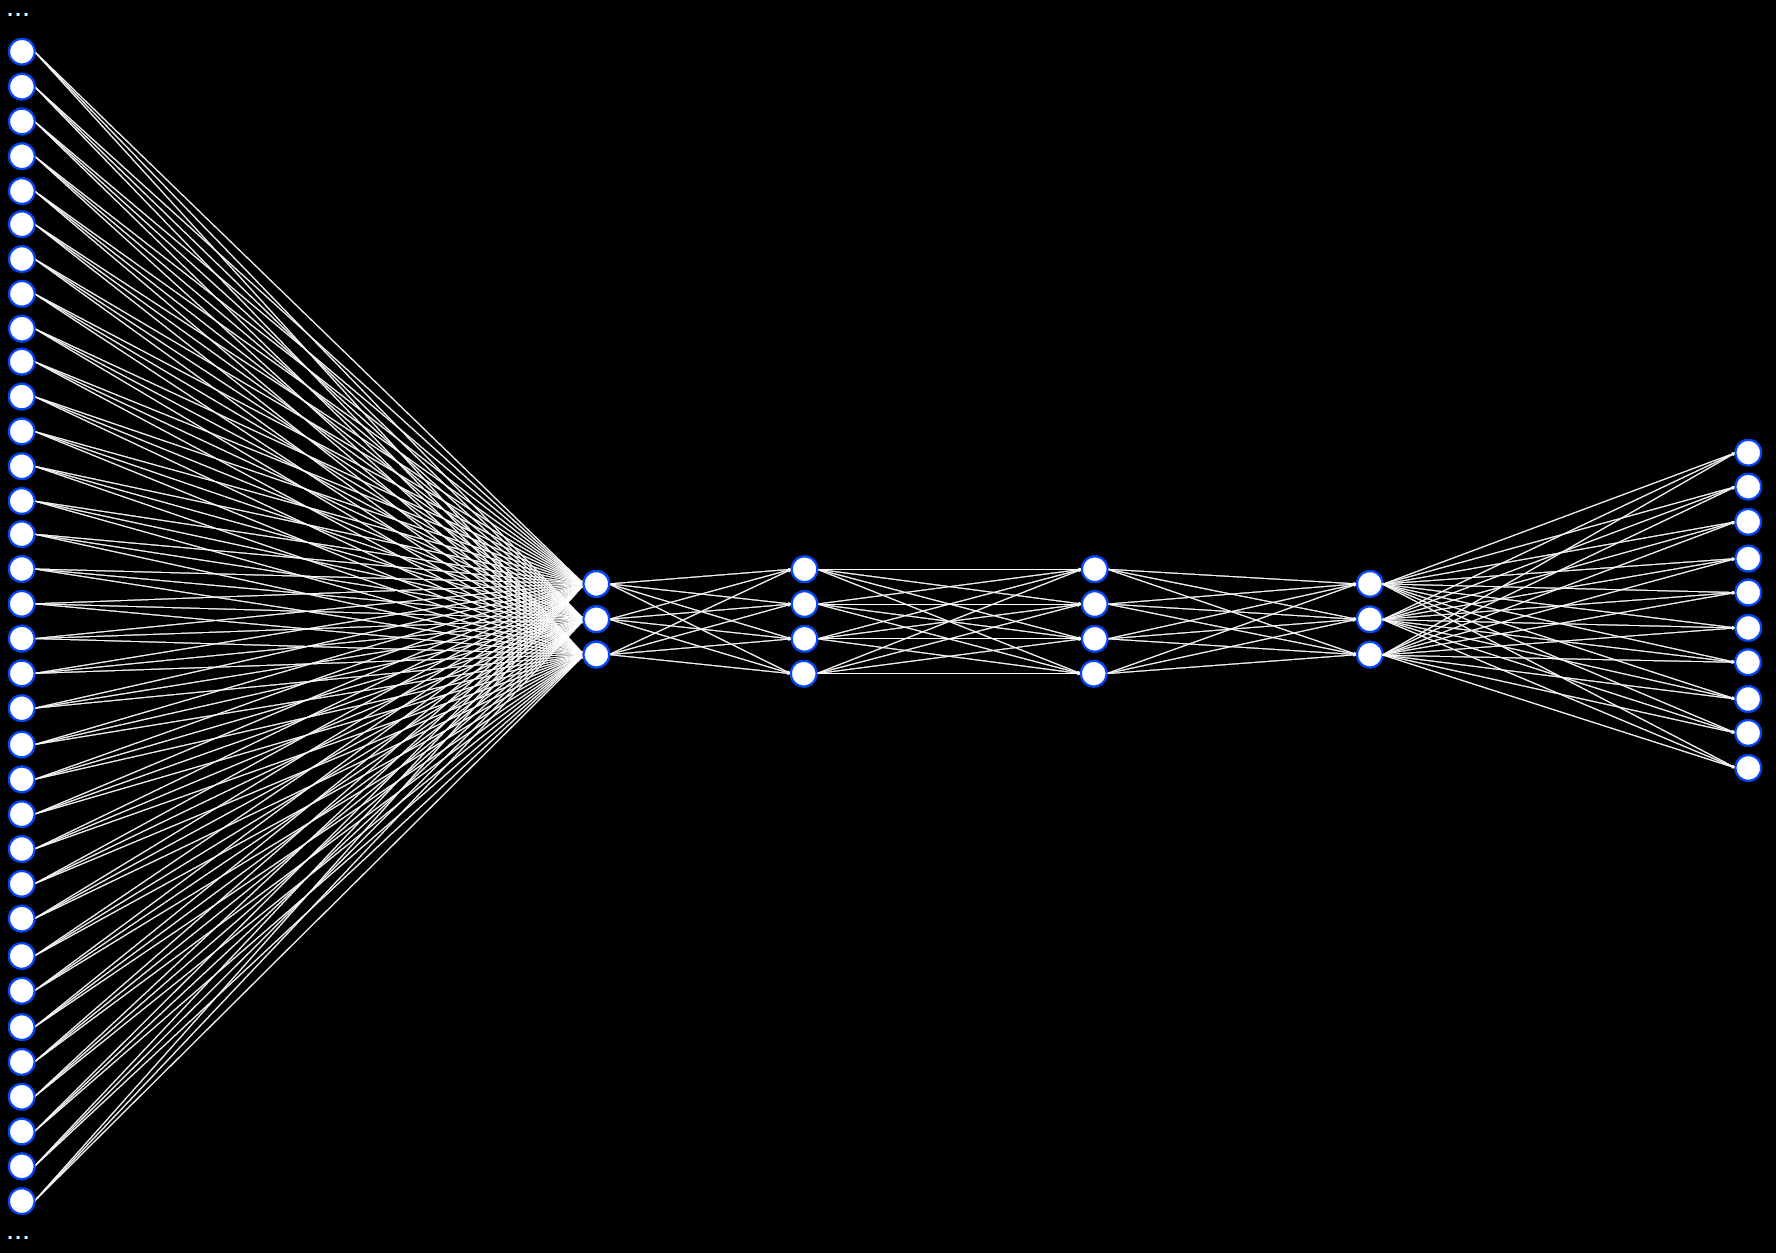

## Image Convolution

L'Image Convolution consiste nell'applicare un filtro che somma ogni valore di un pixel di un'immagine ai suoi vicini, pesato in concordanza a una matrice kernel. In questo modo, l'immagine viene alterata e ciò può aiutare la rete a processarla.

### Esempio

Consideriamo:

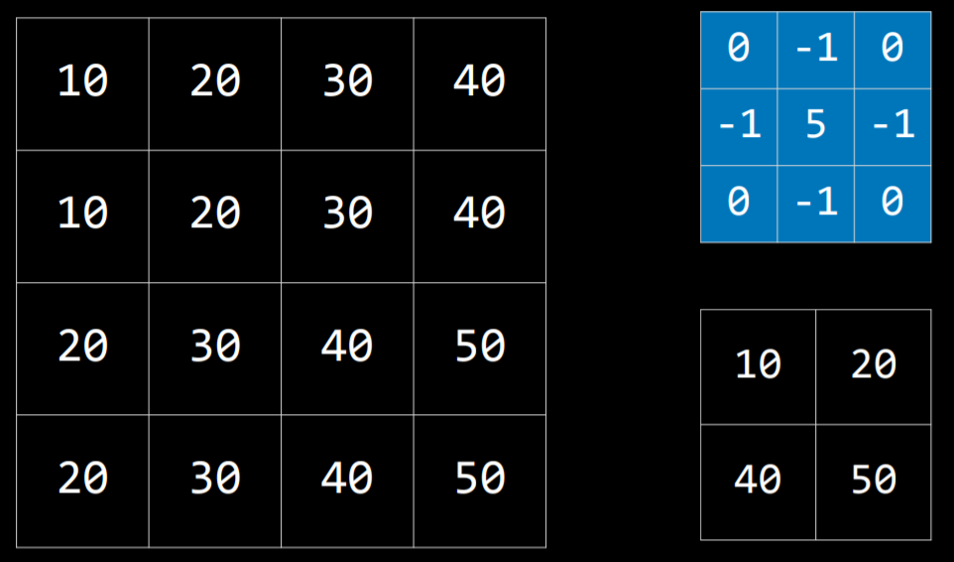

Il kernel è la matrice blu, e l'immagine è la matrice a sinistra. L'immagine risultante filtrata dalla matrice kernel è quella in basso a destra.

Per filtrare l'immagine:
- Iniziamo col pixel di valore 20 in alto a sinistra dell'immagine (Coordinate: 1,1).
- Moltiplichiamo tutti i valori intorno ad esso col valore corrispondente nella matrice kernel a sommiamoli, ottenendo 10
  - $(10 \cdot 0 + 20 \cdot (-1) + 30 \cdot 0 + 10 \cdot (-1) + 20 \cdot 5 + 30 \cdot (-1) + 20 \cdot 0 + 30 \cdot (-1) + 40 \cdot 0) = 10$
- Facciamo la stessa cosa per i pixel 30 (Coordinate: 1,2 e 2,1) e quello 40, coordinate: 2,2.

Questo produce l'immagine filtrata vista in basso a destra.

Kernel diversi possono effettuare task diverse. Per il rilevamento di bordi, viene spesso usato questo kernel:

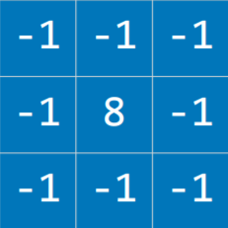

L'idea è che quando un pixel è simile ai suoi vicini, si dovrebbero cancellare a vicenda (un centrale x8 meno otto vicini x(-1)), risultando in 0. Quindi, più sono simili i pixel, più buia è quella parte dell'immagine. Più è luminosa, più sono diversi.

Applicando questo kernel a un'immagine, il risultato è l'immagine con bordi più pronunciati.

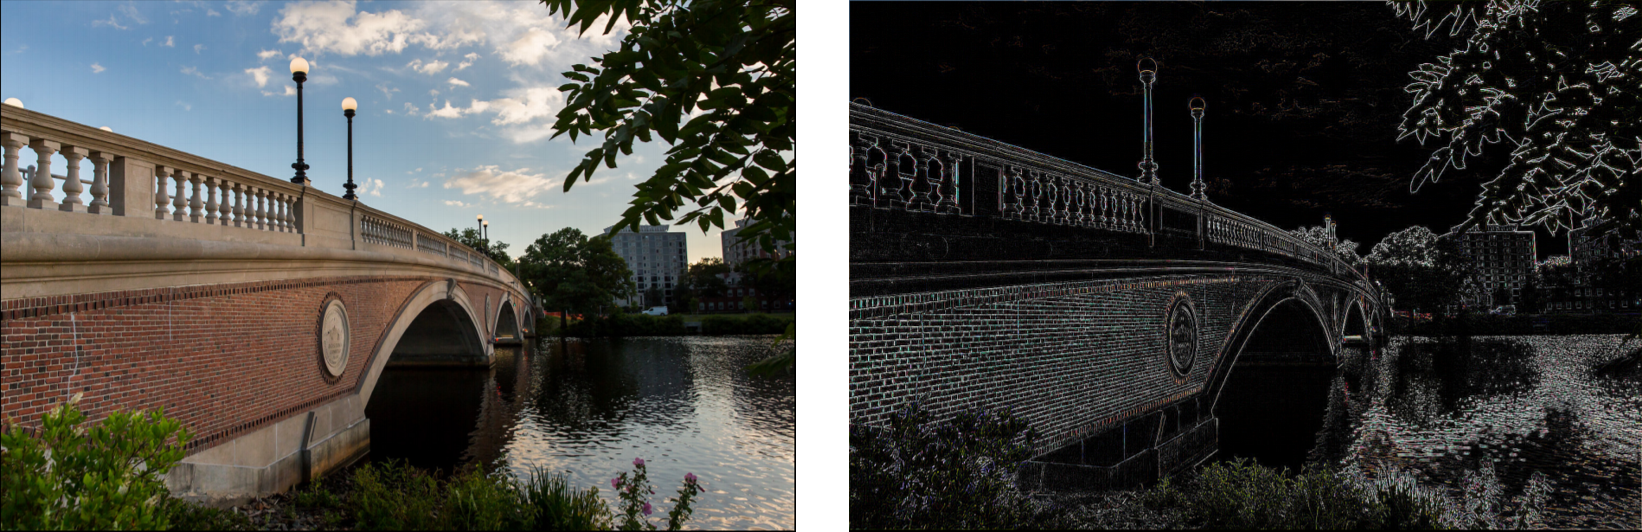

### Implementazione di Image Convolution

Implementazione in: [filter.py](convolution\filter.py)

Usiamo la libreria PIL (Python Imaging Library), che farà il grosso del lavoro.

Processare un'immagine in una rete neurale, comunque, è molto dispendioso a causa del numero di pixel che fanno da input. Un altro modo di affrontare il problema è il **Pooling**

#### Pooling

La dimensione dell'input è ridotta attraverso il campionamento di regioni in input.

Pixel che sono uno vicino l'altro appartengono alla stessa area dell'immagine, quindi è probabile che siano simili.

Di conseguenza, possiamo prendere un pixel per rappresentare un'area intera.

Un modo per fare questo è il **Max-Pooling**.

##### Max-Pooling

Il pixel selezionato è quello col valore più alto degli altri nella stessa regione.

Ad esempio, se dividiamo la matrice a sinistra in quattro matrici 2x2 e facendo max-pooling, otteniamo la matrice a destra.

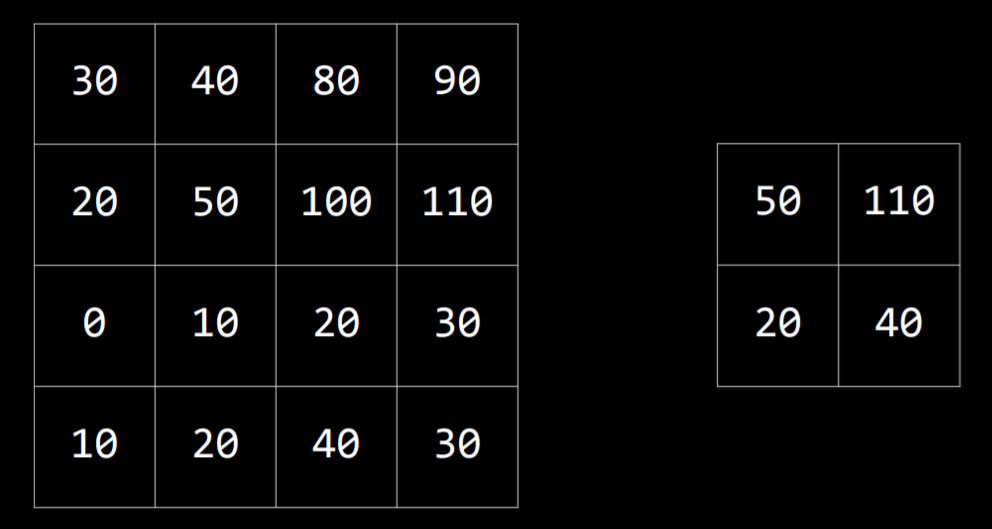

# Convolutional Neural Networks (CNN)

Una CNN è una rete neurale che usa la convoluzione, di solito per analizzare immagini.

Inizia applicando filtri che possono aiutare a distillare alcune features dell'immagine usando kernel diversi. Questi filtri possono essere migliorati nello stesso modo degli altri pesi nelle reti neurali, aggiustando i loro kernel basandosi su errori di output.

Le immagini risultanti vengono poi raggruppate (**pooling**), dopodiché i pixel vengono dati in input a reti neurali tradizionali. Quest'ultima parte del processo si chiama **flattening**.

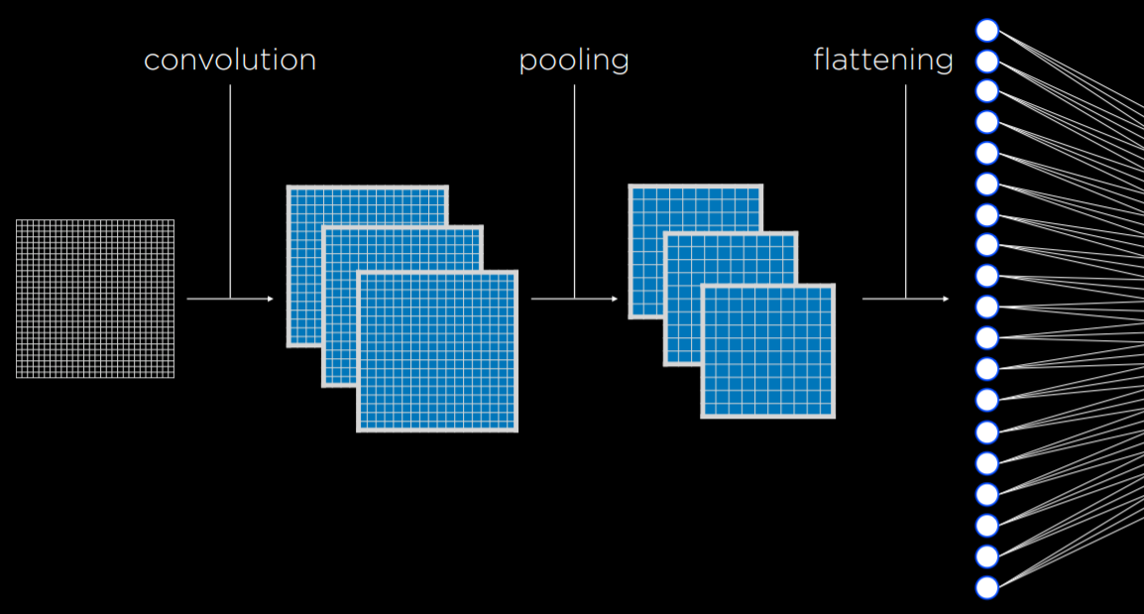

I passi *Convoluzione* e *Pooling* possono essere ripetuti più volte per estrarre features addizionali e ridurre la mole di input della rete neurale.

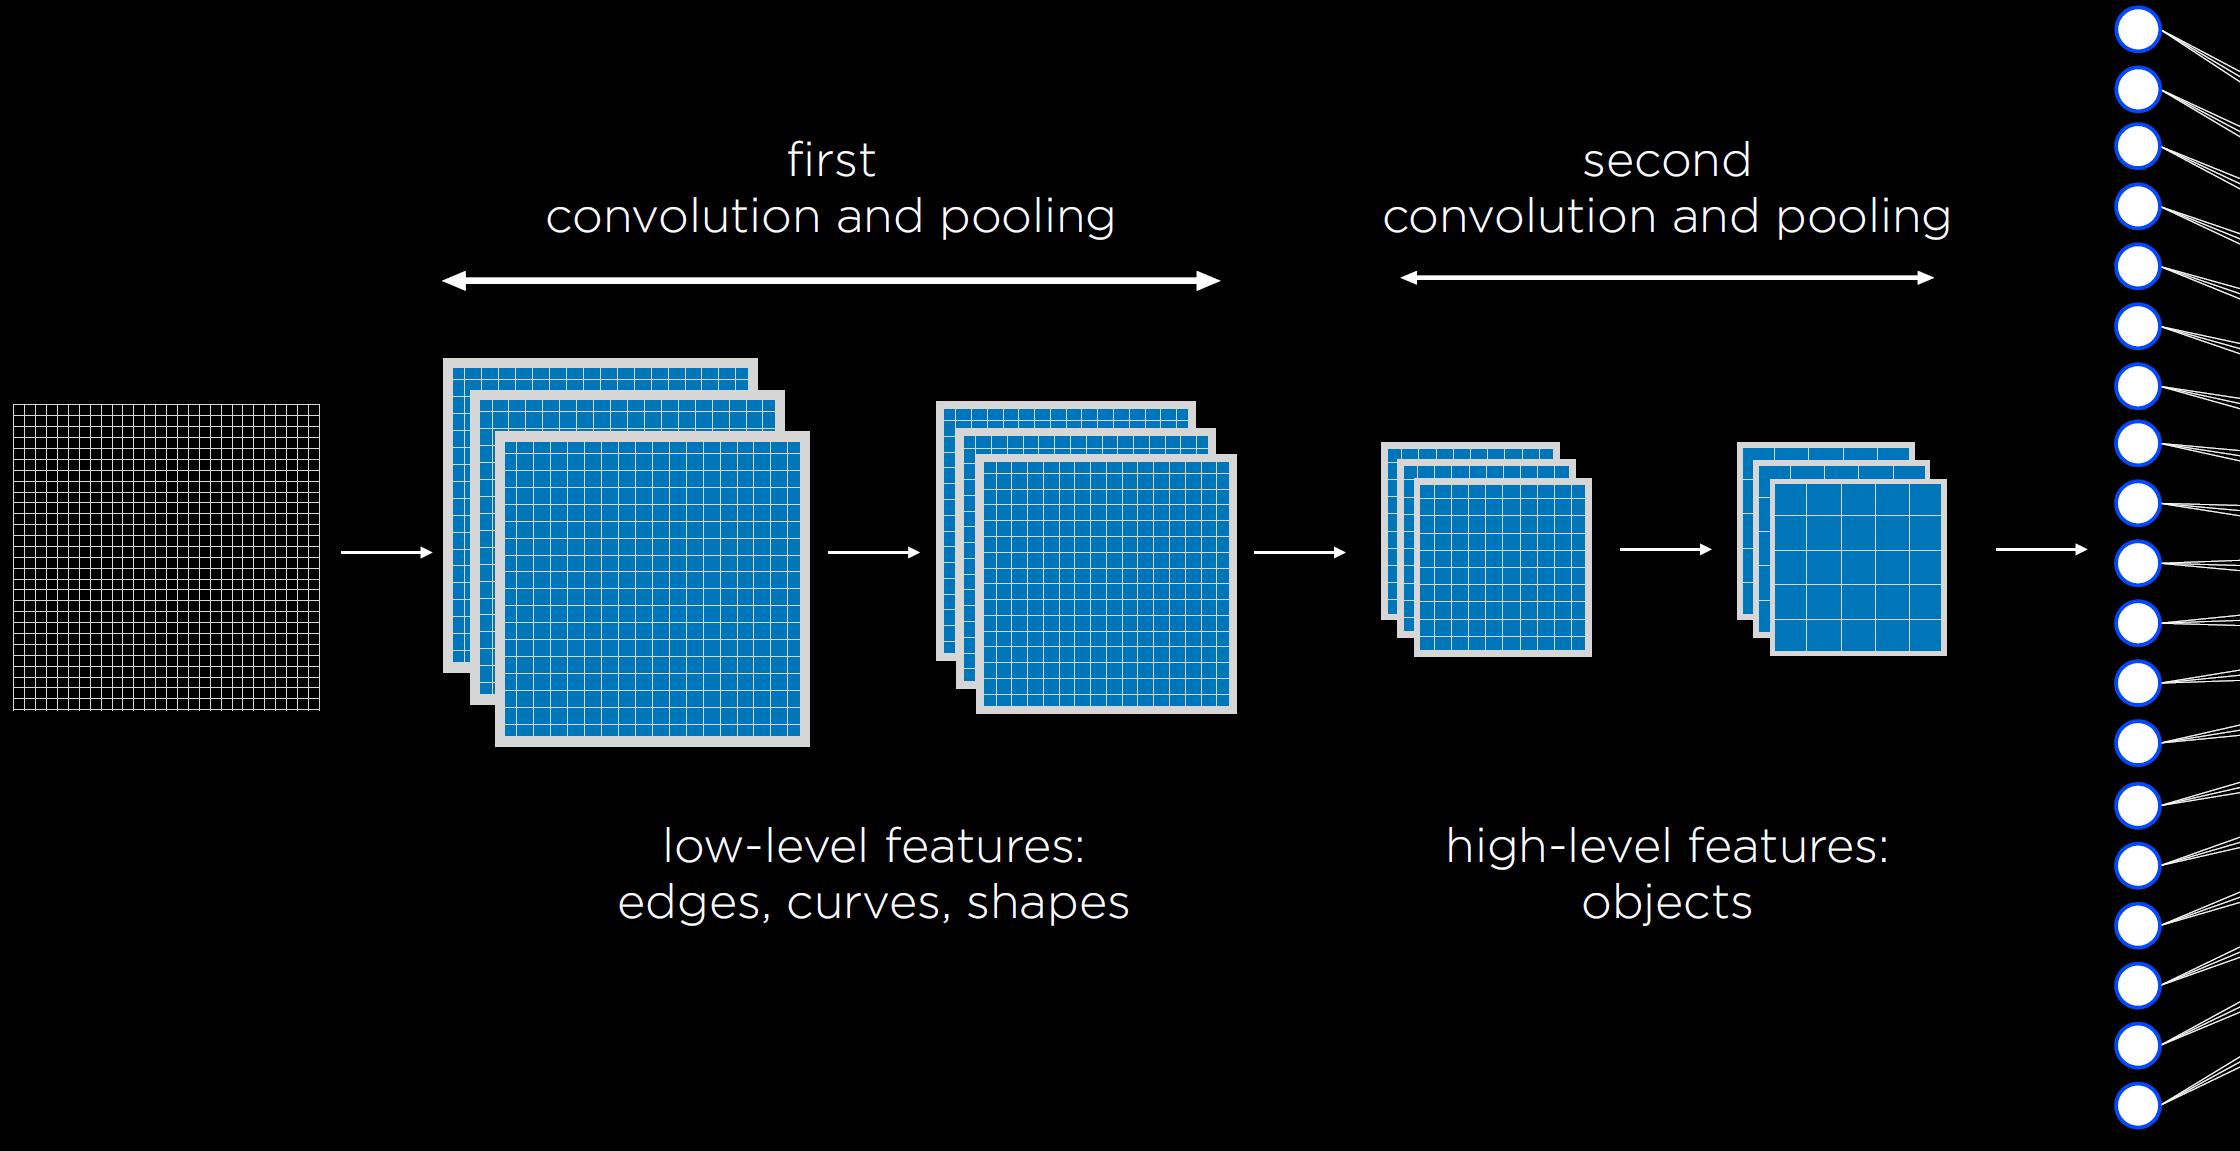

Uno dei benefici di questo processo è che, facendo convoluzione e pooling, la rete neurale diventa meno sensibile alle variazioni.

Ad esempio, se la stessa foto è stata fatta da angoli leggermente diversi, l'input per una CNN sarà simile. Se invece non facciamo convolution e pooling, l'input delle due immagini sarà molto diverso.

## Codice CNN

In codice, una CNN non è molto diversa da una rete neurale tradizionale. TensorFlow offre dataset su cui testare i modelli.

Utilizzeremo `MNIST`, che contiene immagini di numeri in bianco e nero, scritti a mano. Addestreremo la nostra CNN a riconoscere i numeri.

Il codice è preso dal file [handwriting.py](digits\handwriting.py)

In [ ]:
import sys
import tensorflow as tf

# Use MNIST handwriting dataset
mnist = tf.keras.datasets.mnist

# Prepare data for training
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)
x_train = x_train.reshape(
    x_train.shape[0], x_train.shape[1], x_train.shape[2], 1
)
x_test = x_test.reshape(
    x_test.shape[0], x_test.shape[1], x_test.shape[2], 1
)

# Create a convolutional neural network
model = tf.keras.models.Sequential([

    # Convolutional layer. Learn 32 filters using a 3x3 kernel
    tf.keras.layers.Conv2D(
        32, (3, 3), activation="relu", input_shape=(28, 28, 1)
    ),

    # Max-pooling layer, using 2x2 pool size
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten units
    tf.keras.layers.Flatten(),

    # Add a hidden layer with dropout
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    # Add an output layer with output units for all 10 digits
    tf.keras.layers.Dense(10, activation="softmax")
])

# Train neural network
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.fit(x_train, y_train, epochs=10)

# Evaluate neural network performance
model.evaluate(x_test,  y_test, verbose=2)

Dal momento che il modello impiega tempo ad addestrarsi, possiamo salvarne uno già addestrato per un utilizzo futuro.

Questa parte non funziona in Jupyter, quindi meglio riferirsi al file da cui è preso il codice se si vuole testare il funzionamento.

In [ ]:
# Save model to file
if len(sys.argv) == 2:
    filename = sys.argv[1]
    model.save(filename)
    print(f"Model saved to {filename}.")

Ora, se eseguiamo un programma che riceve numeri scritti a mano come input, questo sarà in grado di classificare e comunicare in output il numero, usando il modello.

Per un riferimento a come implementarlo, guardare [recognition.py](digits\recognition.py)

# Feed-Forward Neural Networks

Le reti feed-forward sono il tipo di rete neurale di cui abbiamo parlato finora, dove si forniscono dati in input alla rete, che eventualmente produce un output.

Diagramma delle reti feed-forward:

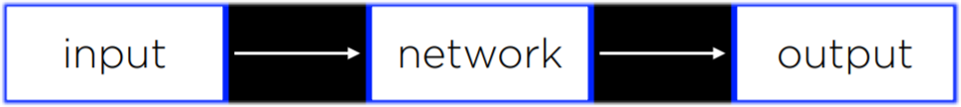

Esistono, in maniera "opposta" alle reti feed-forward, le **Recurrent Neural Networks**

# Recurrent Neural Networks (RNN)

Hanno una struttura non lineare, in cui la rete usa i propri output come input.

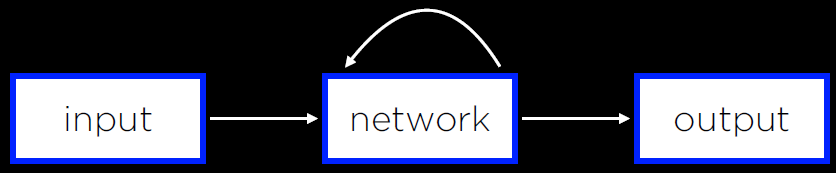

Alcuni bot sono in grado di descrivere i contenuti di un'immagine con frasi scritte. Questo è differente dalla classificazione, poiché l'output è di lunghezza variabile rispetto alle proprietà dell'immagine.

Mentre le reti feed-forward sono incapaci di variare il numero di output, le RNN sono in grado di farlo grazie alla propria struttura.

Nella task di descrizione immagine, una RNN processerebbe l'input attraverso il network per produrre un output, poi darebbe l'output in ingresso al network, riprendendo a processare da quel punto, producendo un altro output, ripetendo finché necessario.

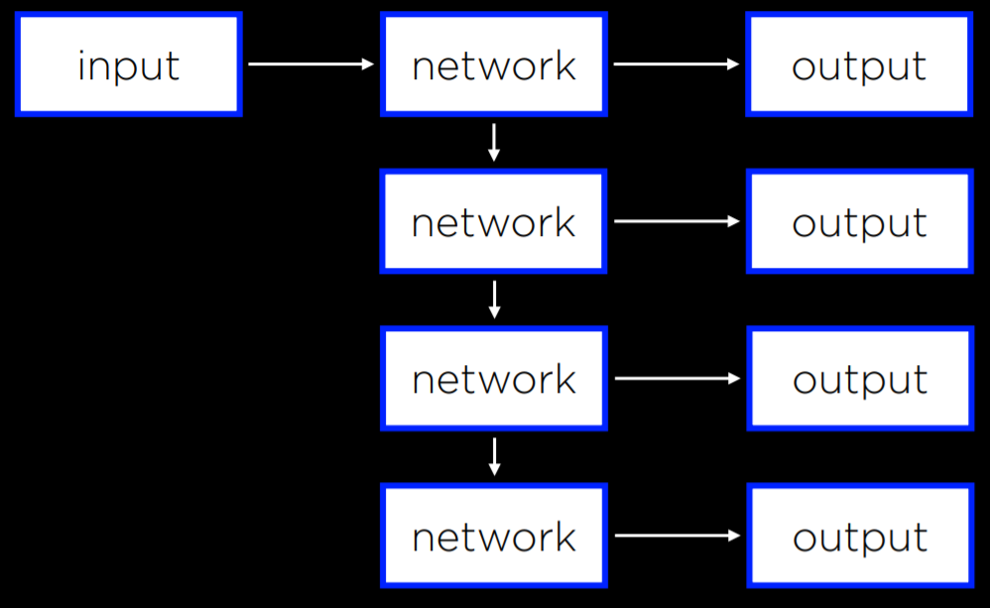

Le RNN sono utili in casi dove la rete ha a che fare con sequenze di oggetti e non un oggetto individuale. Nell'immagine sopra, la rete neurale ha avuto bisogno di produrre una sequenza di parole.

Tuttavia, lo stesso principio può essere applicato all'analisi di file video, che consistono in una sequenza di immagini. Invece di passare tutto il video come input, potremmo passare i vari frame come input. Il network valuta sia il frame che i dati relativi al frame precedente:

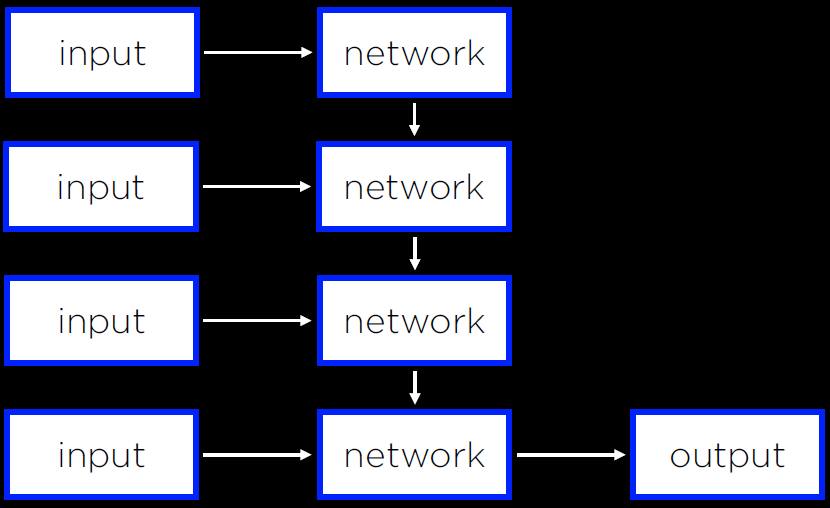

Oppure, in task di traduzione, dove una sequenza di input (parole dalla lingua sorgente) vengono processati per produrra una sequenza di output (parole nella lingua obiettivo)

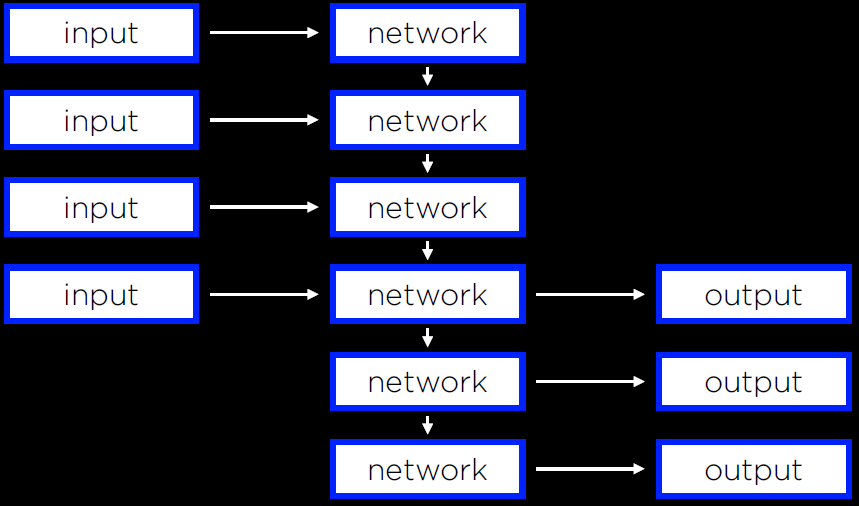